In [5]:
import polars as pl
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

In [6]:
df = pl.read_parquet("flood_model_top30.parquet")

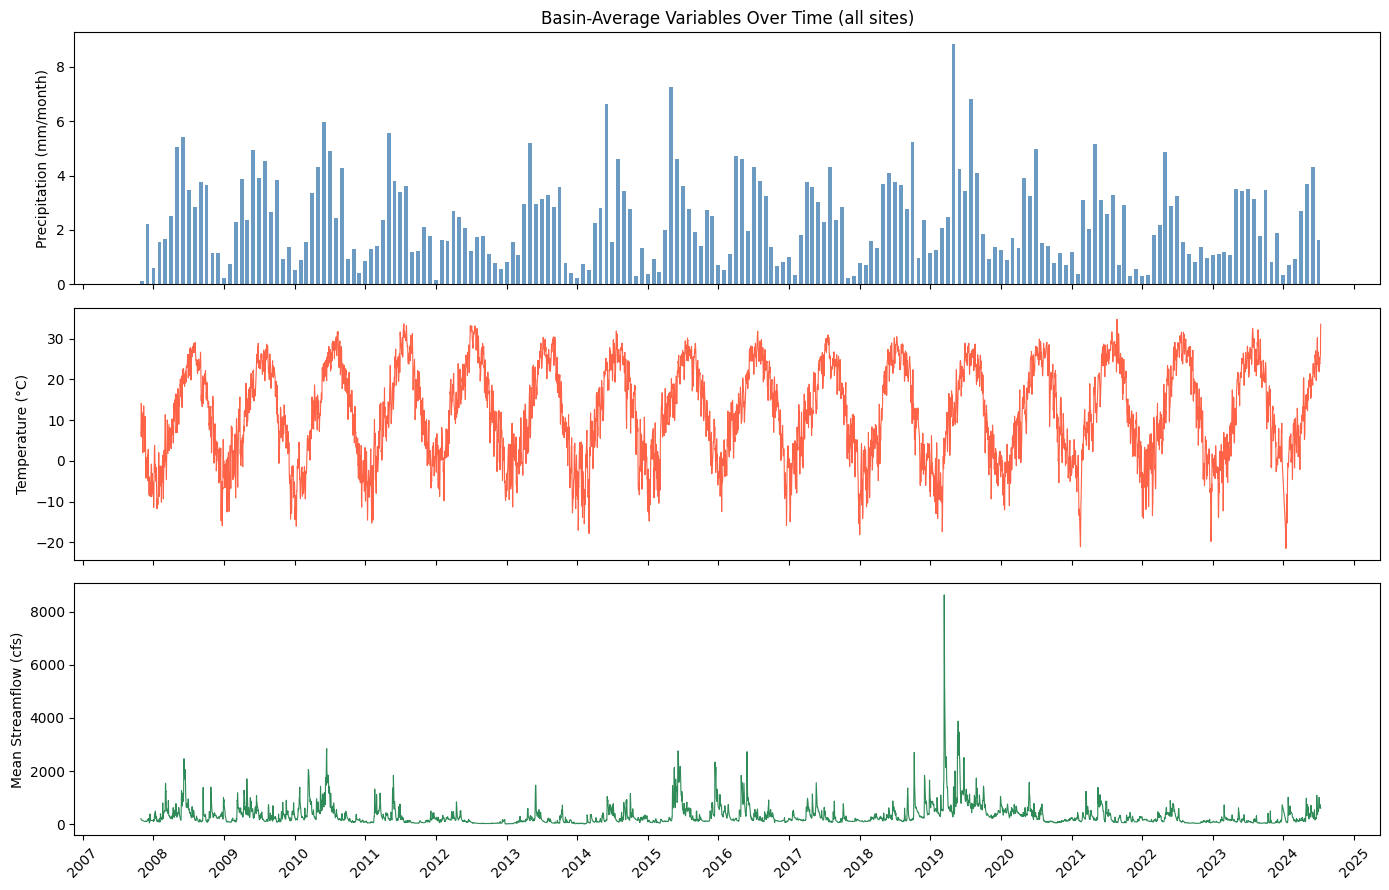

In [8]:
daily = (
    df.with_columns(pl.col("observation_hour").dt.truncate("1d").alias("date"))
    .group_by("date")
    .agg(
        pl.col("precipitation_mm").mean().alias("precip_daily_mean"),
        pl.col("temperature_c").mean(),
        pl.col("streamflow_cfs_mean").mean(),
    )
    .sort("date")
    .to_pandas()
)

# Monthly total precipitation (sum of daily basin-average precip)
monthly_precip = (
    daily.set_index("date")["precip_daily_mean"]
    .resample("MS")
    .sum()
    .reset_index()
)

fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)

axes[0].bar(monthly_precip["date"], monthly_precip["precip_daily_mean"], width=20, color="steelblue", alpha=0.8)
axes[0].set_ylabel("Precipitation (mm/month)")
axes[0].set_title("Basin-Average Variables Over Time (all sites)")

axes[1].plot(daily["date"], daily["temperature_c"], color="tomato", linewidth=0.8)
axes[1].set_ylabel("Temperature (°C)")

axes[2].plot(daily["date"], daily["streamflow_cfs_mean"], color="seagreen", linewidth=0.8)
axes[2].set_ylabel("Mean Streamflow (cfs)")
axes[2].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
axes[2].xaxis.set_major_locator(mdates.YearLocator())
plt.xticks(rotation=45)

fig.tight_layout()
plt.show()